In [57]:
import torch 
from torch import nn
import torch.nn.functional as F
import numpy
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
import os
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights
from torchvision.transforms import Normalize

In [58]:
torch.cuda.is_available()

True

In [59]:
device = torch.device("cuda")

In [60]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/vandit/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


In [61]:
train_transforms = transforms.Compose([
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    transforms.CenterCrop(178),
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

data = datasets.ImageFolder(
    root=os.path.join(path,'img_align_celeba'),
    transform=train_transforms,

)
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])

train_loader = DataLoader(
    data,
    shuffle=True,
    batch_size=512,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)



In [62]:
x,y = next(iter(train_loader))
print(x.shape)

torch.Size([512, 3, 64, 64])


In [63]:
vgg = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval().to(device)
for p in vgg.parameters():
    p.requires_grad = False

def perceptual_loss(op_image,input_image):
    op_image_vgg = vgg(norm(op_image))
    input_image_vgg = vgg(norm(input_image))
    return F.mse_loss(op_image_vgg,input_image_vgg)




Summary for 1 epoch: 
 Reconstruction Loss: 611.76
 KLD Loss: 471.14
 Total Loss: 2113.79
 VGG Loss: 751.02



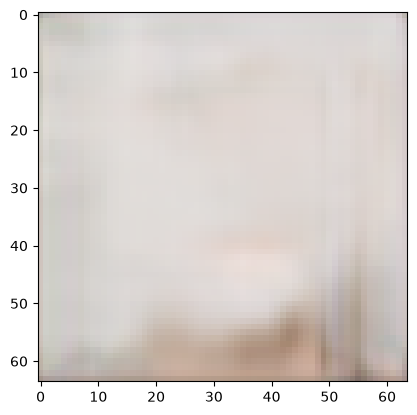



Summary for 2 epoch: 
 Reconstruction Loss: 328.19
 KLD Loss: 428.48
 Total Loss: 1673.67
 VGG Loss: 670.60



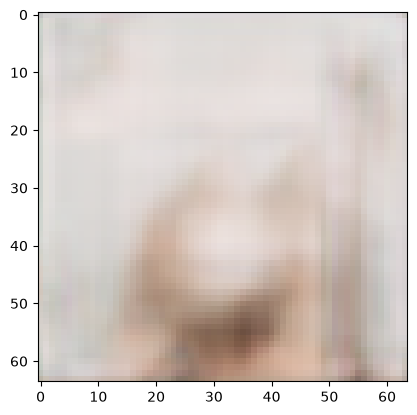



Summary for 3 epoch: 
 Reconstruction Loss: 282.51
 KLD Loss: 353.11
 Total Loss: 1590.85
 VGG Loss: 650.64



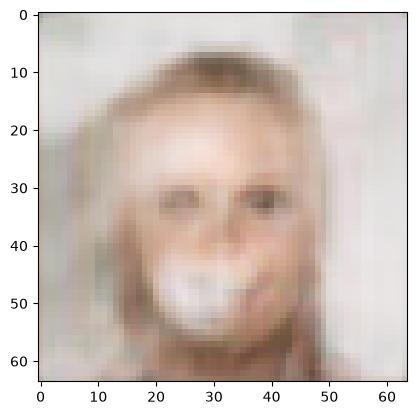



Summary for 4 epoch: 
 Reconstruction Loss: 262.73
 KLD Loss: 321.46
 Total Loss: 1547.68
 VGG Loss: 637.65



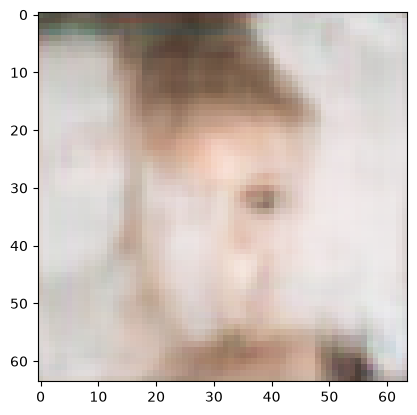



Summary for 5 epoch: 
 Reconstruction Loss: 249.99
 KLD Loss: 298.74
 Total Loss: 1517.32
 VGG Loss: 627.69



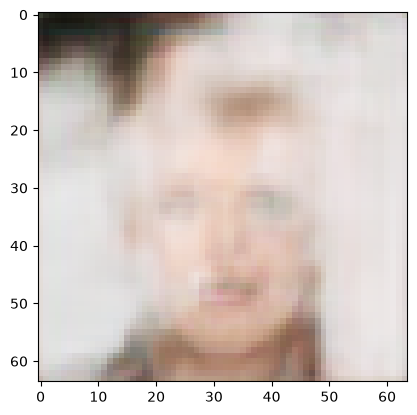



Summary for 6 epoch: 
 Reconstruction Loss: 242.72
 KLD Loss: 279.52
 Total Loss: 1498.49
 VGG Loss: 620.89



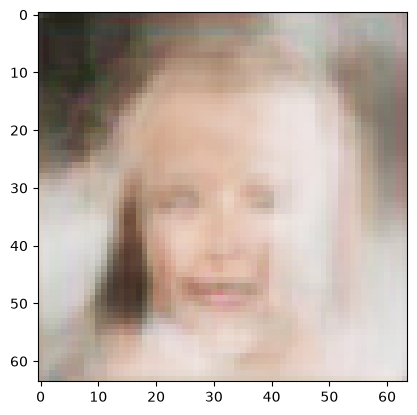



Summary for 7 epoch: 
 Reconstruction Loss: 237.93
 KLD Loss: 263.19
 Total Loss: 1484.22
 VGG Loss: 615.25



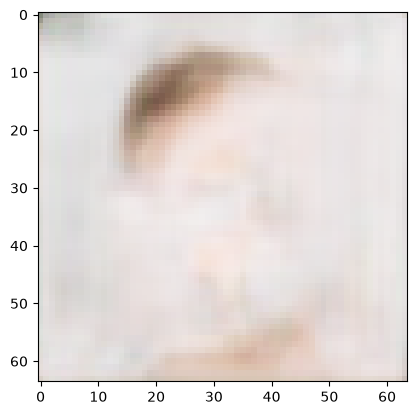



Summary for 8 epoch: 
 Reconstruction Loss: 233.08
 KLD Loss: 247.96
 Total Loss: 1470.46
 VGG Loss: 610.01



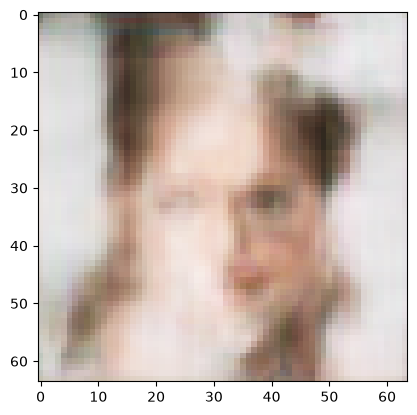



Summary for 9 epoch: 
 Reconstruction Loss: 229.86
 KLD Loss: 234.67
 Total Loss: 1460.87
 VGG Loss: 606.12



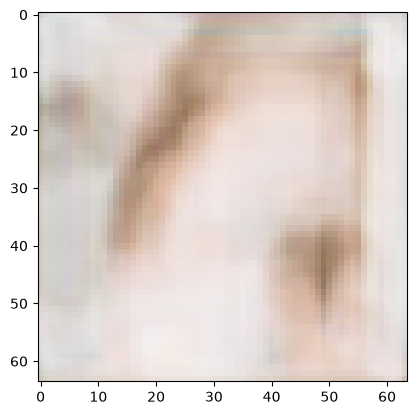



Summary for 10 epoch: 
 Reconstruction Loss: 227.25
 KLD Loss: 222.69
 Total Loss: 1452.06
 VGG Loss: 602.38



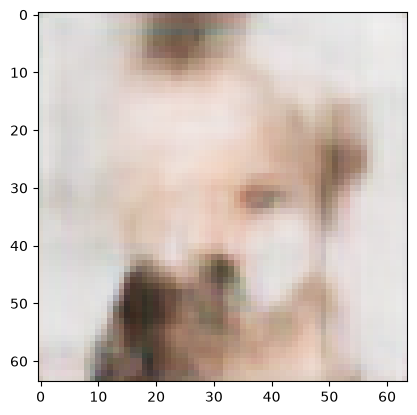



Summary for 11 epoch: 
 Reconstruction Loss: 225.19
 KLD Loss: 212.89
 Total Loss: 1445.24
 VGG Loss: 599.38



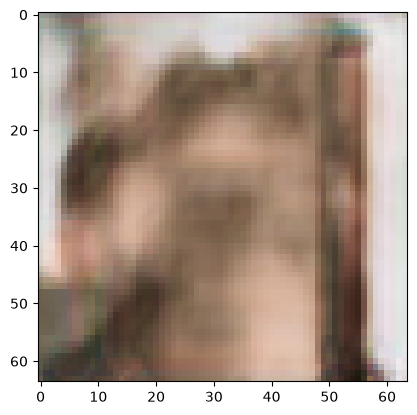



Summary for 12 epoch: 
 Reconstruction Loss: 220.95
 KLD Loss: 209.70
 Total Loss: 1433.45
 VGG Loss: 595.76



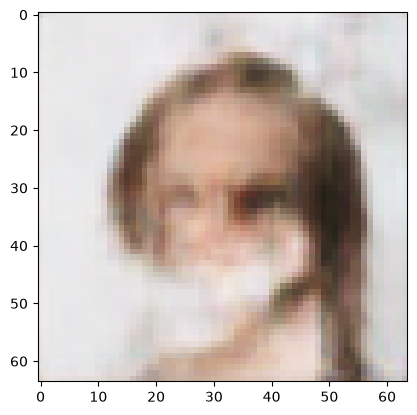



Summary for 13 epoch: 
 Reconstruction Loss: 219.96
 KLD Loss: 205.97
 Total Loss: 1426.95
 VGG Loss: 593.20



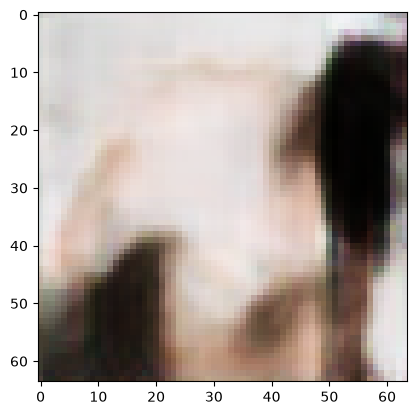



Summary for 14 epoch: 
 Reconstruction Loss: 217.74
 KLD Loss: 203.55
 Total Loss: 1419.50
 VGG Loss: 590.70



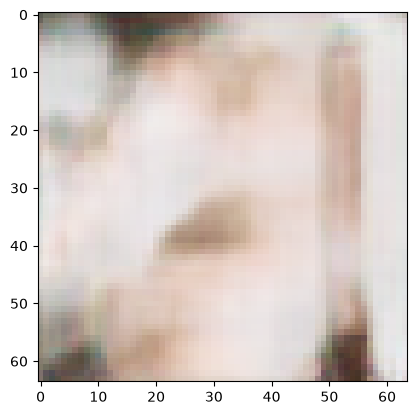



Summary for 15 epoch: 
 Reconstruction Loss: 216.02
 KLD Loss: 201.26
 Total Loss: 1413.54
 VGG Loss: 588.70



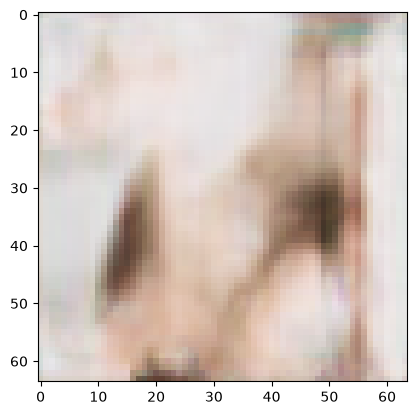



Summary for 16 epoch: 
 Reconstruction Loss: 214.82
 KLD Loss: 199.25
 Total Loss: 1407.55
 VGG Loss: 586.40



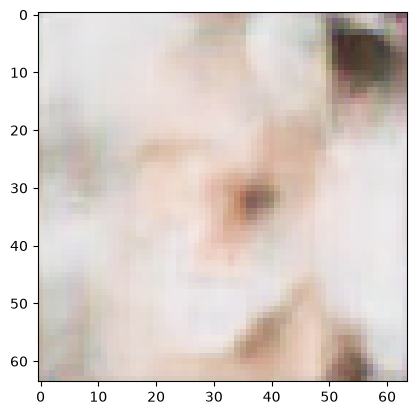



Summary for 17 epoch: 
 Reconstruction Loss: 213.25
 KLD Loss: 197.36
 Total Loss: 1402.34
 VGG Loss: 584.68



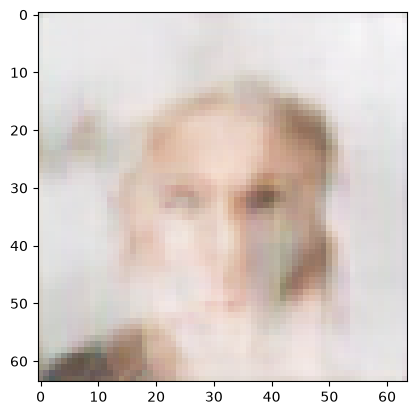



Summary for 18 epoch: 
 Reconstruction Loss: 211.90
 KLD Loss: 196.18
 Total Loss: 1397.16
 VGG Loss: 582.82



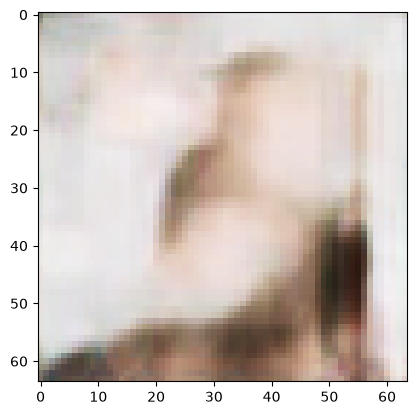



Summary for 19 epoch: 
 Reconstruction Loss: 211.07
 KLD Loss: 194.91
 Total Loss: 1392.93
 VGG Loss: 581.19



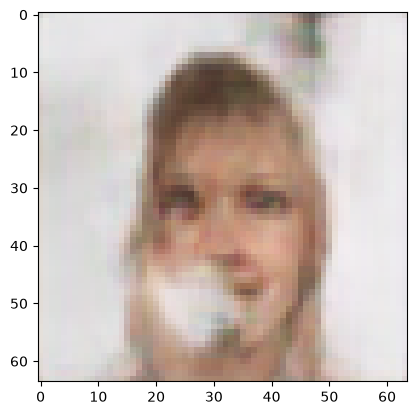



Summary for 20 epoch: 
 Reconstruction Loss: 209.38
 KLD Loss: 193.20
 Total Loss: 1387.51
 VGG Loss: 579.40



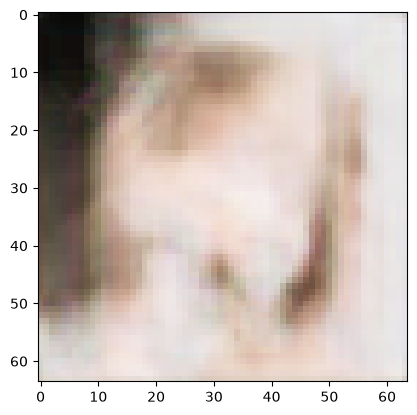



Summary for 21 epoch: 
 Reconstruction Loss: 208.62
 KLD Loss: 192.02
 Total Loss: 1383.83
 VGG Loss: 578.00



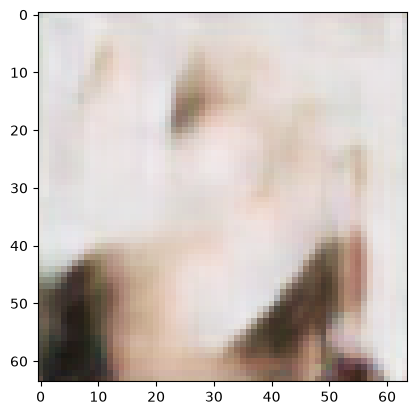



Summary for 22 epoch: 
 Reconstruction Loss: 207.68
 KLD Loss: 191.24
 Total Loss: 1379.87
 VGG Loss: 576.53



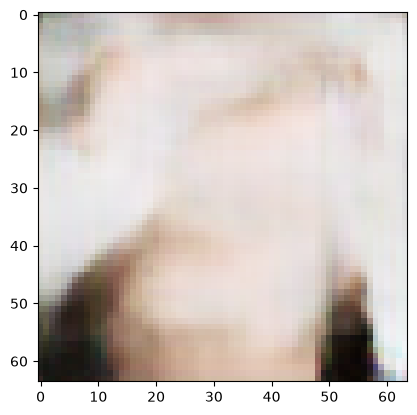



Summary for 23 epoch: 
 Reconstruction Loss: 206.75
 KLD Loss: 190.75
 Total Loss: 1376.24
 VGG Loss: 575.21



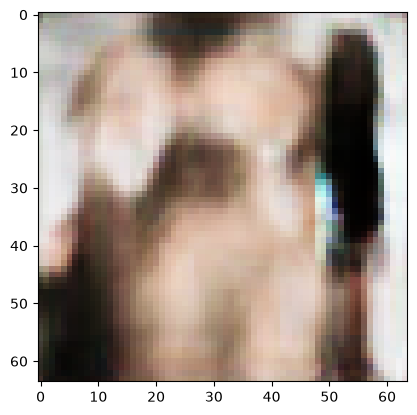



Summary for 24 epoch: 
 Reconstruction Loss: 205.93
 KLD Loss: 190.14
 Total Loss: 1373.04
 VGG Loss: 574.05



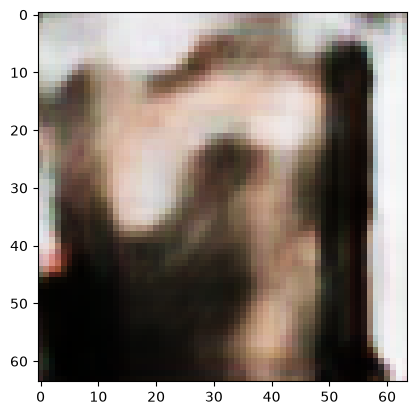



Summary for 25 epoch: 
 Reconstruction Loss: 205.29
 KLD Loss: 189.31
 Total Loss: 1369.94
 VGG Loss: 572.86



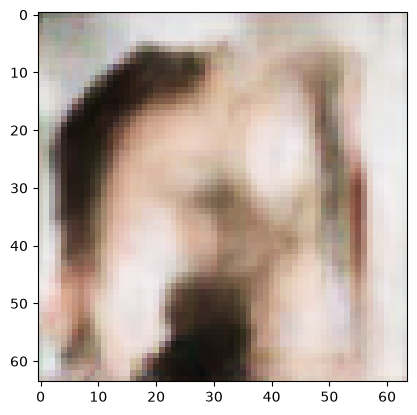

In [ ]:
TOTAL_EPOCH = 100

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3,
                               out_channels=16,
                               kernel_size=3,
                               stride=1)
        self.conv2 = nn.Conv2d(in_channels=16,
                               out_channels=32,
                               kernel_size=3,
                               stride=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3,
                                     stride=2)
        self.conv3 = nn.Conv2d(in_channels=32,
                               out_channels=64,
                               kernel_size=3, 
                               stride=1)
        self.conv4 = nn.Conv2d(in_channels=64,
                               out_channels=128,
                               kernel_size=3,
                               stride=1)
        self.avgpool = nn.AvgPool2d(kernel_size=2,
                                    stride=2)
        self.conv5 = nn.Conv2d(in_channels=128,
                               out_channels=256,
                               kernel_size=3,
                               stride=1)
        self.conv6 = nn.Conv2d(in_channels=256,
                               out_channels=512,
                               kernel_size=3,
                               stride=1)
        self.conv7 = nn.Conv2d(in_channels=512,
                               out_channels=512,
                               kernel_size=3,
                               stride=1)
        self.fc1 = nn.Linear(in_features=2048,
                             out_features=256)
        self.fc2 = nn.Linear(in_features=256,
                             out_features=256)
    def forward(self,x):
        x = self.maxpool1(F.relu(self.conv2(F.relu(self.conv1(x)))))
        x = self.avgpool(F.relu(self.conv4(F.relu(self.conv3(x)))))
        x = self.avgpool(F.relu(self.conv6(F.relu(self.conv5(x)))))
        x = F.relu(self.conv7(x)).flatten(1)
        x = self.fc2(F.relu(self.fc1(x)))
        d = x.shape
        return x[:,:d[1]//2],x[:,d[1]//2:]
        
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(128, 512*4*4)
        def up(in_ch, out_ch):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode="nearest"),
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
        self.up1 = up(512, 256)
        self.up2 = up(256, 128)
        self.up3 = up(128, 64)
        self.up4 = up(64, 32)
        self.final = nn.Conv2d(32, 3, kernel_size=3, padding=1)  # smooths seams

    def forward(self, x):
        x = F.relu(self.fc1(x)).view(-1, 512, 4, 4)
        x = F.relu(self.up1(x))
        x = F.relu(self.up2(x))
        x = F.relu(self.up3(x))
        x = F.relu(self.up4(x))
        return torch.sigmoid(self.final(x))
    


class VariationAutoEncoder(nn.Module):
    def __init__(self ):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def reparametrize(self,mean,std):
        epsilon = torch.randn_like(std)
        z = mean + std * epsilon
        return z
    def forward(self,x):
        diagonal_entries,mean = self.encoder(x)
        std = torch.exp(0.5*diagonal_entries)
        z = self.reparametrize(mean,std)
        op_image_with_channel = self.decoder(z)
        return op_image_with_channel,diagonal_entries,mean
    def only_decoder(self):
        device = next(self.parameters()).device
        with torch.no_grad():
            epsilon = torch.randn(1,128,device=device)
            op_image_with_channel = self.decoder(epsilon)
            return op_image_with_channel
    def generate_image(self,epoch):
        op_image = self.only_decoder().squeeze(0)
        plt.imshow(op_image.permute(1,2,0).detach().cpu())
        # plt.grid(False)
        plt.show()
        # plt.imsave(f"Generated_images/{epoch}.png", op_image.permute(1,2,0).detach().cpu())
        

    
vae = VariationAutoEncoder()
vae = vae.to(device=device)
optimizer = torch.optim.Adam(params=vae.parameters(), lr=2e-3)
def vae_loss(op_images,input_images,diagonal_entries, mean,beta,vgg_loss):
    reconstruction_loss = F.mse_loss(op_images, input_images, reduction="sum")/input_images.shape[0]
    kld_loss = -0.5*torch.sum(1 + diagonal_entries - mean**2 - torch.exp(diagonal_entries))/input_images.shape[0]
    return reconstruction_loss + beta * kld_loss +  60 * vgg_loss, reconstruction_loss.item(), kld_loss.item(),vgg_loss.item()


train_loss = []
Recon_loss = []
KL = []
VGG = []
epochs = list(range(1,TOTAL_EPOCH+1))

def get_beta(epoch, warmup=10, beta_max=0.1):
    return beta_max * min(1.0, epoch / warmup)
# pass beta into vae_loss:  recon + beta * kld
def train_vae():
    for epoch in range(TOTAL_EPOCH):
        total_train_loss = 0
        reconstruction_loss = 0
        kld_loss = 0
        vgg_loss = 0
        beta = get_beta(epoch)
        for batch_x,_ in train_loader:
            scale = batch_x[0].numel() 
            batch_x = batch_x.to(device)
            with torch.autocast(device_type="cuda",dtype=torch.bfloat16):
                op_image_with_channel, logvar_diagonal_entries, mean = vae(batch_x)
                percept_loss = perceptual_loss(op_image_with_channel.float(),batch_x)
                loss,recon,kld,vgg = vae_loss(op_image_with_channel.float(),batch_x,logvar_diagonal_entries.float(),mean.float(),beta,percept_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss+=loss.item()
            reconstruction_loss+=recon
            kld_loss+=kld
            vgg_loss+=vgg
            with torch.no_grad():
                reconstructed_image,_,_ = vae(batch_x[:1])
                # print(reconstructed_image.shape)
                # print("reconstructed images shown below:\n")
                # plt.imshow(reconstructed_image.squeeze(0).permute(1,2,0).detach().cpu())
                # plt.show()
                
        train_loss.append(total_train_loss/len(train_loader))
        Recon_loss.append(reconstruction_loss/len(train_loader))
        VGG.append(vgg_loss/len(train_loader))
        KL.append(kld_loss/len(train_loader))
        print(f"\n\nSummary for {epoch+1} epoch: \n Reconstruction Loss: {reconstruction_loss/len(train_loader):.2f}\n KLD Loss: {kld_loss/len(train_loader):.2f}\n Total Loss: {total_train_loss/len(train_loader):.2f}\n VGG Loss: { 30 * vgg_loss/len(train_loader):.2f}\n")
        vae.generate_image(epoch)

        if (epoch+1)%5==0:
            torch.save(vae.state_dict(), f"Generated_images/vae_{epoch}.pt")
    torch.save(vae.state_dict(), f"final_vae_weight.pt")
train_vae()
plt.figure(figsize=(8,6))
plt.plot(epochs,train_loss, label = 'train loss' )
plt.plot(epochs,Recon_loss, label = 'Reconstruction loss')
plt.plot(epochs,KL, label = 'KL divergence' )
plt.yscale("log")
plt.xlabel("epochs")
plt.ylabel('loss')
plt.title("Train loss vs epochs")
plt.grid(True)
plt.legend()
# plt.savefig("Generated_images/loss.jpg")
plt.show()